## *) import libraries.

In [ ]:
# Warnings
import warnings
warnings.filterwarnings("ignore")

# EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

## a)  Load the "co2_emissions_data.csv" dataset.

In [ ]:
df = pd.read_csv("co2_emissions_data.csv")
df

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Emission Class
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196,MODERATE
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221,HIGH
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136,MODERATE
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255,HIGH
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244,HIGH
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30,219,HIGH
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,29,232,HIGH
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,27,240,HIGH
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,29,232,HIGH


## b)  Perform analysis on the dataset to:

### i) check whether there are missing values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
 12  Emissi

In [ ]:
df.isnull().sum()

Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
Emission Class                      0
dtype: int64

### ii) check whether numeric features have the same scale

In [ ]:
targets = ['CO2 Emissions(g/km)', 'Emission Class']
numeric_features = [col for col in df.select_dtypes(include=['int64','float64']).columns
                    if col not in targets]
categorical_features = [col for col in df.select_dtypes(include='object').columns
                    if col not in targets]

In [ ]:
df[numeric_features].describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000


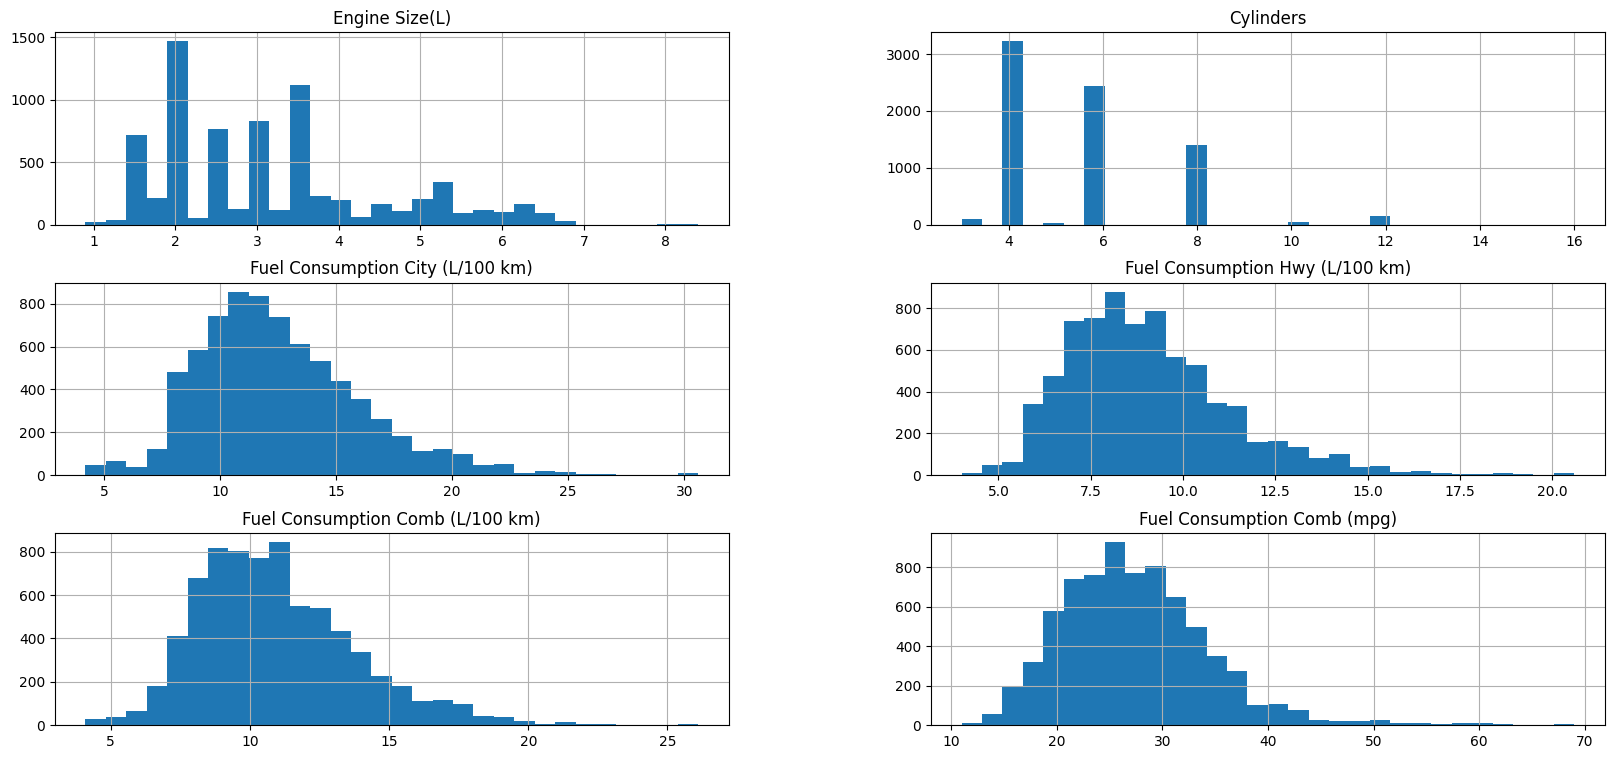

In [ ]:
df[numeric_features].hist(bins=30, figsize=(20,9))
plt.show()

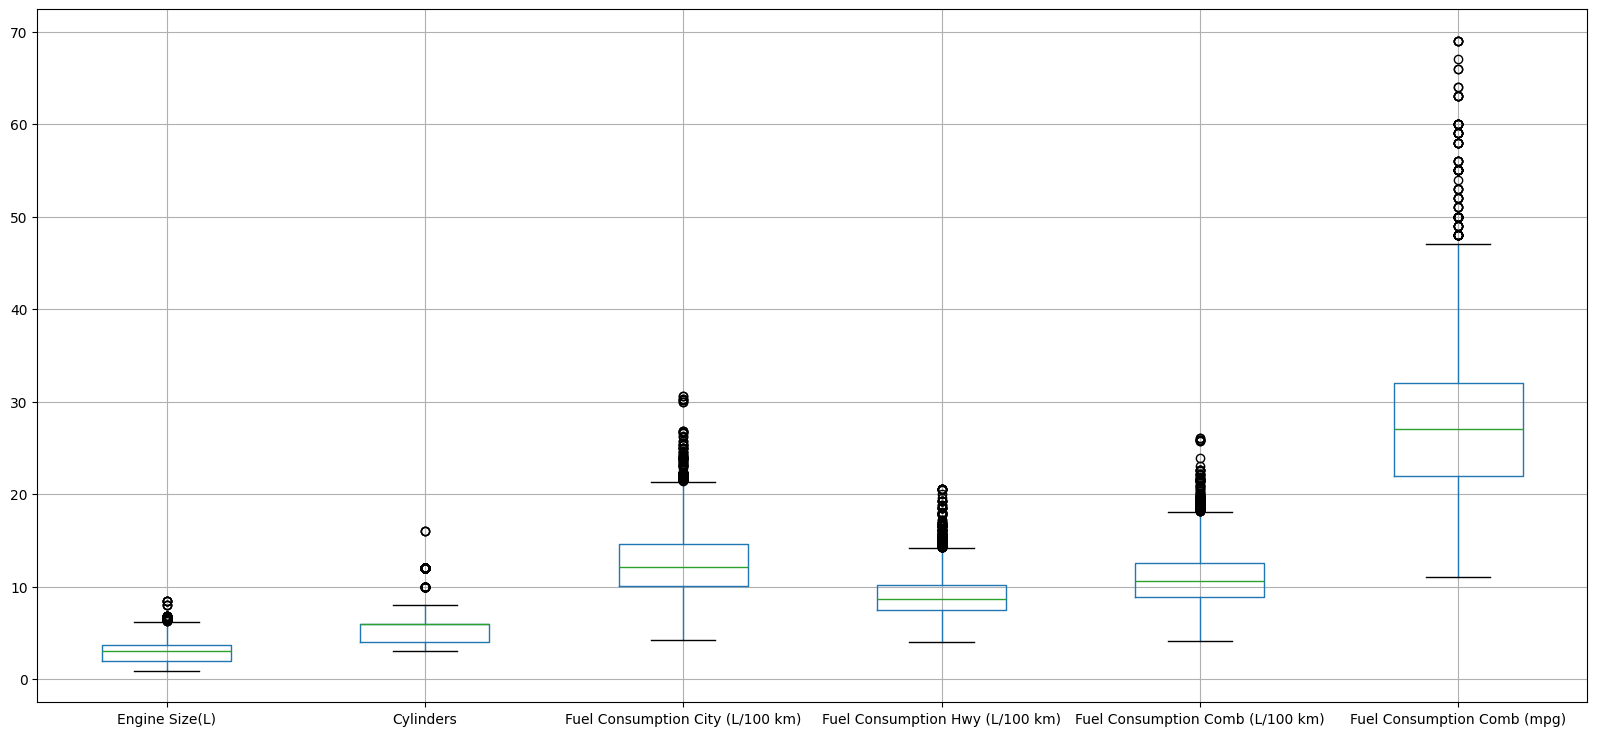

In [ ]:
df[numeric_features].boxplot(figsize=(20,9))
plt.show()

### iii) visualize a pairplot in which diagonal subplots are histograms

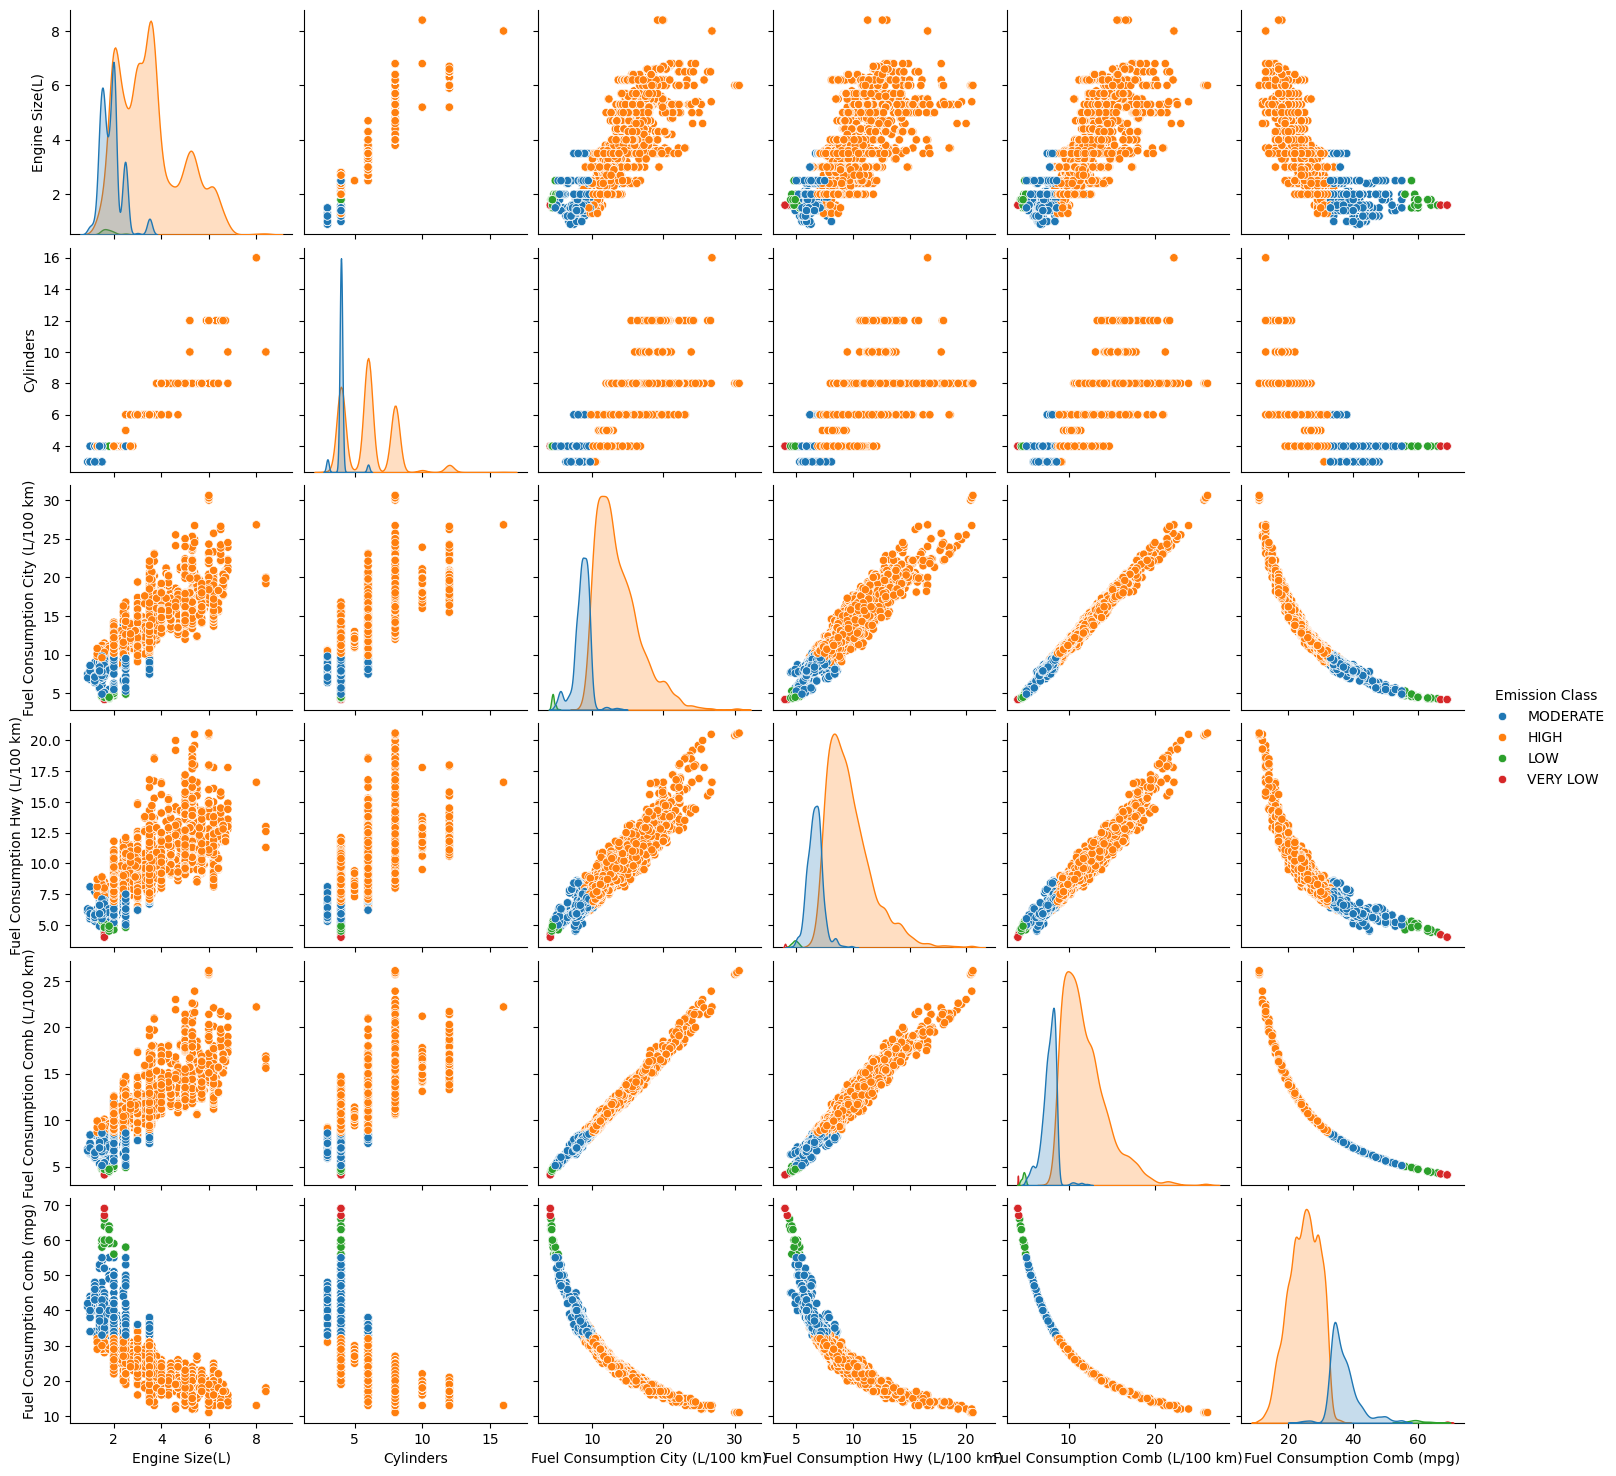

In [ ]:
sns.pairplot(df[numeric_features + ['Emission Class']], hue='Emission Class')

### iv) visualize a correlation heatmap between numeric columns

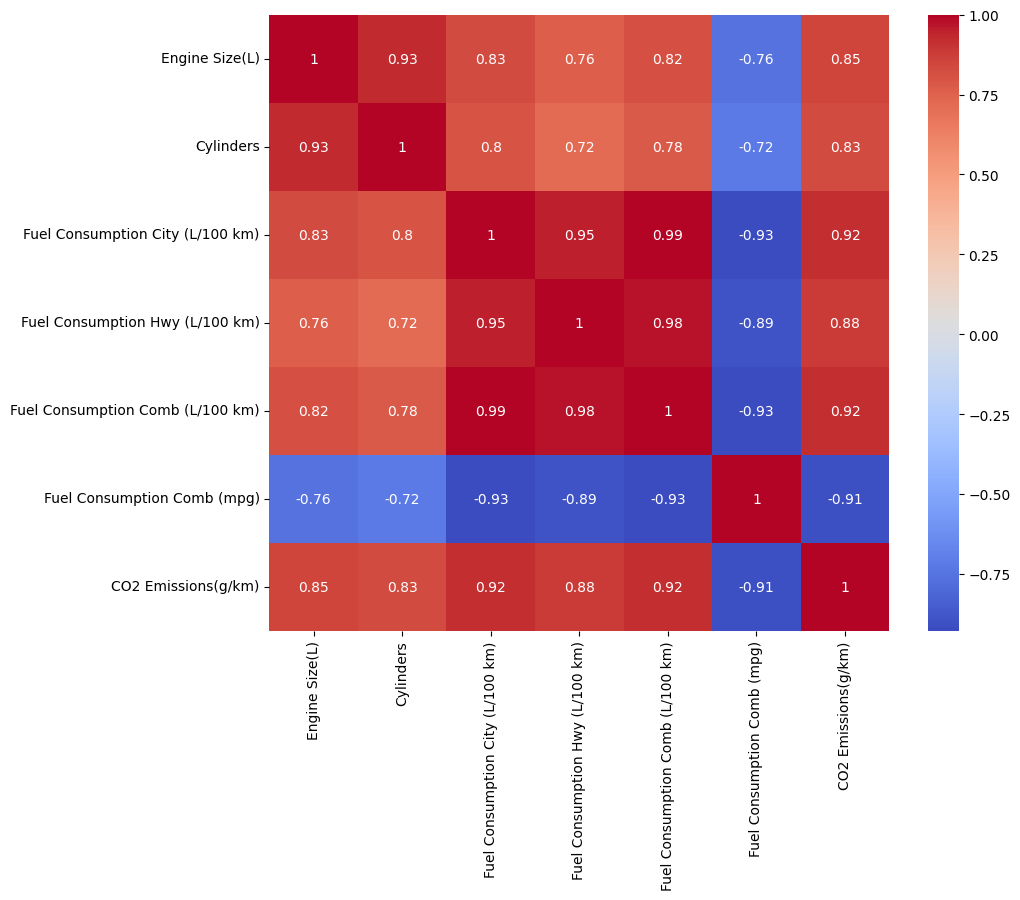

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_features + ['CO2 Emissions(g/km)']].corr(), annot=True, cmap='coolwarm')
plt.show()

## c)  Preprocess the data such that:

### i) the features and targets are separated

In [ ]:
X = df.drop(columns = targets).copy()
Y = df[targets].copy()
print(X)

       Make        Model   Vehicle Class  Engine Size(L)  Cylinders  \
0     ACURA          ILX         COMPACT             2.0          4   
1     ACURA          ILX         COMPACT             2.4          4   
2     ACURA   ILX HYBRID         COMPACT             1.5          4   
3     ACURA      MDX 4WD     SUV - SMALL             3.5          6   
4     ACURA      RDX AWD     SUV - SMALL             3.5          6   
...     ...          ...             ...             ...        ...   
7380  VOLVO  XC40 T5 AWD     SUV - SMALL             2.0          4   
7381  VOLVO  XC60 T5 AWD     SUV - SMALL             2.0          4   
7382  VOLVO  XC60 T6 AWD     SUV - SMALL             2.0          4   
7383  VOLVO  XC90 T5 AWD  SUV - STANDARD             2.0          4   
7384  VOLVO  XC90 T6 AWD  SUV - STANDARD             2.0          4   

     Transmission Fuel Type  Fuel Consumption City (L/100 km)  \
0             AS5         Z                               9.9   
1              M6

In [ ]:
print(Y)

      CO2 Emissions(g/km) Emission Class
0                     196       MODERATE
1                     221           HIGH
2                     136       MODERATE
3                     255           HIGH
4                     244           HIGH
...                   ...            ...
7380                  219           HIGH
7381                  232           HIGH
7382                  240           HIGH
7383                  232           HIGH
7384                  248           HIGH

[7385 rows x 2 columns]


### ii) categorical features and targets are encoded

In [ ]:
df[categorical_features + ['Emission Class']].nunique()

Make                42
Model             2053
Vehicle Class       16
Transmission        27
Fuel Type            5
Emission Class       4
dtype: int64

In [ ]:
# Model column is dropped because it has too many unique values (2053), which would create thousands of columns and hurt the model.

X = X.drop(columns=['Model'])

In [ ]:
print(Y['Emission Class'].unique())

encoder = OrdinalEncoder(categories=[['VERY LOW','LOW','MODERATE','HIGH']])
Y['Emission Class'] = encoder.fit_transform(Y[['Emission Class']])
print(Y['Emission Class'].unique())

['MODERATE' 'HIGH' 'LOW' 'VERY LOW']
[2. 3. 1. 0.]


In [ ]:
# Dummy encoding is used (k−1) to avoid multicollinearity by dropping one category so the encoded features are not perfectly correlated.

categorical_cols = [col for col in categorical_features if col != 'Model']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Make_ALFA ROMEO,Make_ASTON MARTIN,Make_AUDI,Make_BENTLEY,...,Transmission_AV6,Transmission_AV7,Transmission_AV8,Transmission_M5,Transmission_M6,Transmission_M7,Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z
0,2.0,4,9.9,6.7,8.5,33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2.4,4,11.2,7.7,9.6,29,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,1.5,4,6.0,5.8,5.9,48,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,3.5,6,12.7,9.1,11.1,25,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,3.5,6,12.1,8.7,10.6,27,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7380,2.0,4,10.7,7.7,9.4,30,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7381,2.0,4,11.2,8.3,9.9,29,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7382,2.0,4,11.7,8.6,10.3,27,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7383,2.0,4,11.2,8.3,9.9,29,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


### iii) the data is shuffled and split into training and testing sets

The dataset was **shuffled before splitting** to **ensure randomness** and **prevent ordering bias**.

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    shuffle=True,
    random_state=42
)
X_train

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Make_ALFA ROMEO,Make_ASTON MARTIN,Make_AUDI,Make_BENTLEY,...,Transmission_AV6,Transmission_AV7,Transmission_AV8,Transmission_M5,Transmission_M6,Transmission_M7,Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z
6590,3.0,6,11.4,8.1,9.9,29,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
6274,4.0,6,14.7,10.3,12.7,22,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2251,3.0,6,13.8,9.0,11.7,24,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
3149,3.4,6,11.3,7.9,9.8,29,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4362,2.0,4,10.1,7.0,8.7,32,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5191,2.0,4,10.3,7.4,9.0,31,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
5226,3.5,6,10.6,7.3,9.1,31,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
5390,3.5,6,11.7,8.8,10.4,27,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
860,2.5,4,9.5,7.4,8.6,33,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
X_test

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Make_ALFA ROMEO,Make_ASTON MARTIN,Make_AUDI,Make_BENTLEY,...,Transmission_AV6,Transmission_AV7,Transmission_AV8,Transmission_M5,Transmission_M6,Transmission_M7,Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z
7261,3.0,6,12.4,9.0,10.9,26,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4489,4.4,8,17.3,11.6,14.7,19,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1539,6.2,8,16.1,11.4,14.0,20,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3532,5.3,8,14.6,10.3,12.7,22,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
6418,4.0,6,14.3,11.9,13.2,21,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7185,2.0,4,10.9,7.7,9.5,30,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1740,2.0,4,12.6,9.7,11.3,25,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4609,1.4,4,8.8,6.6,7.8,36,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1844,3.5,6,11.9,8.2,10.2,28,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
Y_train

,CO2 Emissions(g/km),Emission Class
6590,231,3.0
6274,299,3.0
2251,273,3.0
3149,230,3.0
4362,204,3.0
...,...,...
5191,210,3.0
5226,214,3.0
5390,242,3.0
860,198,2.0


In [ ]:
Y_test

,CO2 Emissions(g/km),Emission Class
7261,253,3.0
4489,344,3.0
1539,322,3.0
3532,297,3.0
6418,308,3.0
...,...,...
7185,221,3.0
1740,260,3.0
4609,184,2.0
1844,235,3.0


### iv) numeric features are scaled

We use **Standardization (StandardScaler)** instead of **Normalization (Min-Max)** because the data contains **outliers and is right-skewed**, and **min-max scaling is highly sensitive to extreme values**, while **standardization is more robust in such cases**.


**fit_transform** is applied to **the training set** to **learn the scaling parameters (mean and standard deviation)**, while **transform** is applied to **the test set** using those same parameters to avoid data leakage.

In [ ]:
scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])
X_train[numeric_features]

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
6590,-0.121493,0.205342,-0.335091,-0.429379,-0.376817,0.217020
6274,0.614166,0.205342,0.607277,0.564406,0.592571,-0.756204
2251,-0.121493,0.205342,0.350268,-0.022831,0.246361,-0.478140
3149,0.172770,0.205342,-0.363647,-0.519723,-0.411438,0.217020
4362,-0.857153,-0.885139,-0.706327,-0.926271,-0.792268,0.634115
...,...,...,...,...,...,...
5191,-0.857153,-0.885139,-0.649213,-0.745583,-0.688405,0.495083
5226,0.246336,0.205342,-0.563544,-0.790755,-0.653784,0.495083
5390,0.246336,0.205342,-0.249421,-0.113175,-0.203712,-0.061044
860,-0.489323,-0.885139,-0.877666,-0.745583,-0.826889,0.773147


In [ ]:
X_test[numeric_features]

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
7261,-0.121493,0.205342,-0.049525,-0.022831,-0.030607,-0.200076
4489,0.908430,1.295823,1.349749,1.151642,1.284990,-1.173299
1539,2.232618,1.295823,1.007070,1.061298,1.042643,-1.034267
3532,1.570524,1.295823,0.578721,0.564406,0.592571,-0.756204
6418,0.614166,0.205342,0.493051,1.287158,0.765676,-0.895235
...,...,...,...,...,...,...
7185,-0.857153,-0.885139,-0.477874,-0.610067,-0.515300,0.356052
1740,-0.857153,-0.885139,0.007589,0.293373,0.107877,-0.339108
4609,-1.298549,-0.885139,-1.077563,-1.106959,-1.103857,1.190243
1844,0.246336,0.205342,-0.192308,-0.384207,-0.272954,0.077988


### d) Linear Regression using Gradient Descent (From Scratch)

Selecting two features that have a strong relationship with CO2 emissions but not a strong relationship with each other
- Fuel Consumption Comb (L/100 km): correlation with CO2 = 0.92
- Cylinders: correlation with CO2 = 0.83
- Their correlation with each other = 0.78 (least redundant)

In [ ]:
features = ['Fuel Consumption Comb (L/100 km)','Cylinders']
# dataframes are converted to numpy arrays for matrix operations in gradient descent.
X_train_lin = X_train[features].values
X_test_lin = X_test[features].values
y_train_lin = Y_train['CO2 Emissions(g/km)'].values
y_test_lin = Y_test['CO2 Emissions(g/km)'].values
#a column of ones is added for the intercept term.
X_train_lin = np.c_[np.ones(len(X_train_lin)), X_train_lin]
X_test_lin  = np.c_[np.ones(len(X_test_lin)),  X_test_lin]

print(X_train_lin)
print(y_train_lin)

[[ 1.         -0.37681659  0.20534188]
 [ 1.          0.59257065  0.20534188]
 [ 1.          0.24636092  0.20534188]
 ...
 [ 1.         -0.20371173  0.20534188]
 [ 1.         -0.82688924 -0.88513888]
 [ 1.          0.31560287  1.29582264]]
[231 299 273 ... 242 198 279]


Theta initalization

In [ ]:
theta = np.zeros(X_train_lin.shape[1])
theta

array([0., 0., 0.])

computing cost using cost function

In [ ]:
def compute_cost(X, y, theta):
    m = len(y)  #number of rows (training examples)
    predictions = X @ theta
    cost = (1/(2*m)) * np.sum((predictions - y) ** 2)
    return cost

Gradient Descent

In [ ]:
def gradient_descent(X, y, theta, alpha, num_iters):
    m = len(y)
    cost_history = []
    for i in range(num_iters):
        pred = X @ theta
        errors = pred - y
        gradient = (1/m) * (X.T @ errors)
        theta -= alpha * gradient
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history

Run gradient descent

In [ ]:
alpha = 0.01
num_iters = 1000
theta, cost_history = gradient_descent(X_train_lin, y_train_lin, theta, alpha, num_iters)
print("Theta:", theta)

Theta: [250.92874009  38.83389537  18.64207536]


Plot cost history

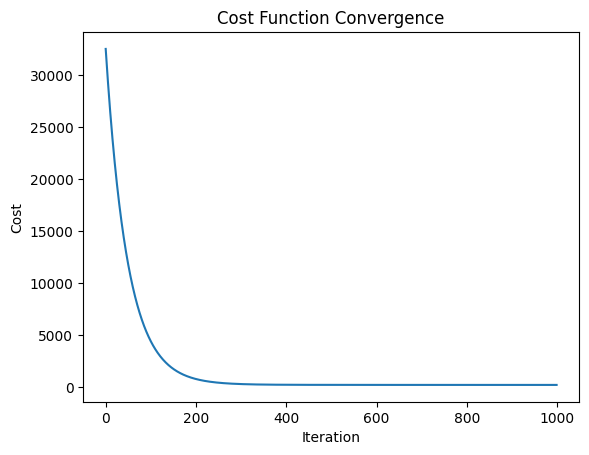

In [ ]:
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function Convergence')
plt.show()

Model evaluation (using R2 score)

In [ ]:
predictions = X_test_lin @ theta
r2 = r2_score(y_test_lin, predictions)
print("R² Score:", r2)

R² Score: 0.8757257721828272


## e) Fit a logistic regression model to the data to predict the emission class.

i - Use the two features that you previously used to predict the CO2 emission amount.

here is it => features = ['Fuel Consumption Comb (L/100 km)','Cylinders'] it was defined in the previous cells, I just used it in a markdown as a highlight to remind you of the 2 features we used to predict the CO2 emission amount.

In [ ]:
X_train_for_log = X_train[features]
X_test_for_log = X_test[features]

y_train_for_log = Y_train['Emission Class']
y_test_for_log = Y_test['Emission Class']

ii - The logistic regression model should be a stochastic gradient descent classifier.

In [ ]:
log_model = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)

# Train
log_model.fit(X_train_for_log, y_train_for_log)

# Predict
y_pred_log = log_model.predict(X_test_for_log)

iii - Calculate the accuracy of the model using the test set
      since it's not clear where you want us to calculate by
      hand or actually use the accuracy score pre-built
      function, i'm gonna do both

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test_for_log, y_pred_log)

print("Accuracy:", accuracy)

Accuracy: 0.970886932972241


now let's do it by hand, just to be safe if that was what's required

In [ ]:
def manual_accuracy(y_true, y_pred):
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    return correct / total

manual_acc = manual_accuracy(y_test_for_log, y_pred_log)
print("Manual Accuracy:", manual_acc)

Manual Accuracy: 0.970886932972241
